# **Day 11: Hypothesis Testing for Machine Learning**
*Module 2 - Probability, Statistics and Optimisation*

"Model B is 1.2% more accurate than model A." Is that a **real** improvement or **luck** in the test split? Reviewers ask this question. Hypothesis tests answer it.

> A hypothesis test asks whether an observed difference could easily be due to chance. The p-value is the probability of seeing such a difference if there were really no effect. A small p-value means "chance alone is an unlikely explanation".
>
> *Example:* Model A is 1% more accurate than model B on 200 test pixels. A test tells us whether that 1% is a real improvement or just luck in this particular test set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(11)

## **1. The Logic**
1. State the **null hypothesis** $H_0$ (no effect, no difference) and the alternative $H_1$.
2. Compute a **test statistic** from the data.
3. The **p-value** = probability of a statistic at least this extreme **if $H_0$ were true**.
4. If $p < \alpha$ (usually 0.05), reject $H_0$.

| | $H_0$ true | $H_0$ false |
|---|---|---|
| Reject $H_0$ | **Type I error** (false positive), rate $\alpha$ | Correct (power $= 1-\beta$) |
| Keep $H_0$ | Correct | **Type II error** (false negative), rate $\beta$ |

**A p-value is NOT** the probability that $H_0$ is true, and a large p-value does **not** prove "no difference".

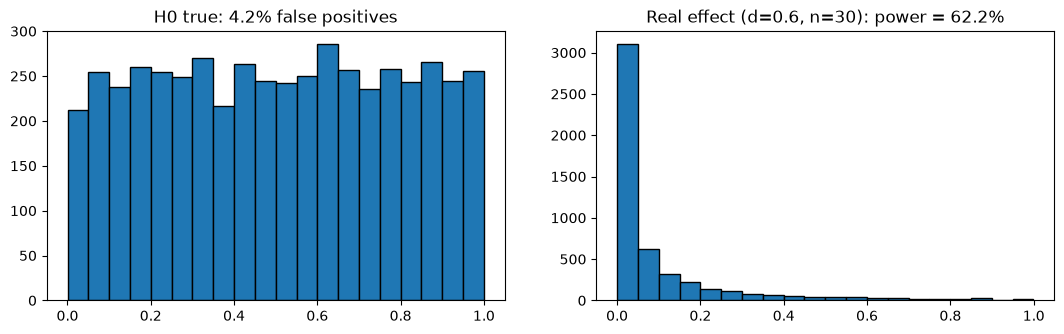

In [2]:
# Under H0, p-values are uniformly distributed: 5% fall below 0.05 by chance
p_null = [stats.ttest_ind(rng.normal(0, 1, 30), rng.normal(0, 1, 30)).pvalue for _ in range(5000)]
p_alt = [stats.ttest_ind(rng.normal(0, 1, 30), rng.normal(0.6, 1, 30)).pvalue for _ in range(5000)]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].hist(p_null, bins=20, edgecolor="k"); axes[0].set_title(f"H0 true: {np.mean(np.array(p_null) < 0.05):.1%} false positives")
axes[1].hist(p_alt, bins=20, edgecolor="k"); axes[1].set_title(f"Real effect (d=0.6, n=30): power = {np.mean(np.array(p_alt) < 0.05):.1%}")
plt.show()

## **2. t-tests**

| Test | Question | scipy | Non-parametric alternative |
|---|---|---|---|
| One-sample | Is the mean equal to $\mu_0$? | `ttest_1samp` | Wilcoxon signed-rank |
| Two-sample (Welch) | Do two independent groups differ? | `ttest_ind(equal_var=False)` | Mann-Whitney U |
| Paired | Do paired measurements differ? | `ttest_rel` | Wilcoxon signed-rank |

**Example:** two models evaluated on the **same 10 cross-validation folds**. Samples are paired by fold, so use a paired test.

In [3]:
fold_A = np.array([0.81, 0.84, 0.79, 0.86, 0.83, 0.80, 0.85, 0.82, 0.84, 0.81])
fold_B = fold_A + rng.normal(0.012, 0.008, 10)            # B is slightly better on every fold
print("Mean A = %.3f, mean B = %.3f" % (fold_A.mean(), fold_B.mean()))
print("Unpaired Welch t-test p =", round(stats.ttest_ind(fold_A, fold_B, equal_var=False).pvalue, 4), " <- ignores pairing")
print("Paired t-test p         =", round(stats.ttest_rel(fold_A, fold_B).pvalue, 6))
print("Wilcoxon signed-rank p  =", round(stats.wilcoxon(fold_A, fold_B).pvalue, 6))

Mean A = 0.825, mean B = 0.839
Unpaired Welch t-test p = 0.2532  <- ignores pairing
Paired t-test p         = 0.004718
Wilcoxon signed-rank p  = 0.001953


The fold-to-fold variation is large, but B beats A **consistently on every fold**. The paired test sees this; the unpaired test does not. (Caution: CV folds overlap, so even paired t-tests on CV scores are optimistic. Day 42 uses the corrected resampled t-test.)

## **3. Chi-square Test of Independence**
Are two categorical variables related? E.g. is the misclassification rate different between regions?

In [4]:
table = pd.DataFrame({"correct": [420, 380, 310], "wrong": [30, 45, 70]}, index=["plains", "plateau", "hills"])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(table, f"\n\nchi2 = {chi2:.1f}, dof = {dof}, p = {p:.2e}")
print("Error rate by region:", (table.wrong / table.sum(1)).round(3).to_dict())

         correct  wrong
plains       420     30
plateau      380     45
hills        310     70 

chi2 = 28.4, dof = 2, p = 6.67e-07
Error rate by region: {'plains': 0.067, 'plateau': 0.106, 'hills': 0.184}


## **4. More Than Two Groups: ANOVA and Kruskal-Wallis**

In [5]:
g1, g2, g3 = rng.normal(5.0, 1, 50), rng.normal(5.2, 1, 50), rng.normal(6.0, 1, 50)
print("One-way ANOVA  p =", f"{stats.f_oneway(g1, g2, g3).pvalue:.2e}")
print("Kruskal-Wallis p =", f"{stats.kruskal(g1, g2, g3).pvalue:.2e}")
from statsmodels.stats.multicomp import pairwise_tukeyhsd
data = np.r_[g1, g2, g3]; groups = np.repeat(["A", "B", "C"], 50)
print(pairwise_tukeyhsd(data, groups))

One-way ANOVA  p = 9.59e-04
Kruskal-Wallis p = 1.60e-03
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   0.0362 0.9838 -0.4611 0.5334  False
     A      C   0.7117 0.0026  0.2145  1.209   True
     B      C   0.6756 0.0045  0.1784 1.1728   True
---------------------------------------------------


ANOVA tells us *some* group differs; Tukey's HSD tells us *which* pairs differ while controlling the error rate.

## **5. McNemar's Test: Comparing Two Classifiers on One Test Set**
Both classifiers predict the same $n$ test samples. Only the **disagreements** matter:
- $b$ = A correct, B wrong; $c$ = A wrong, B correct.
- $\chi^2 = \frac{(\lvert b-c\rvert-1)^2}{b+c}$ (continuity-corrected), 1 degree of freedom.

This is the test recommended by Dietterich (1998) and widely used in remote sensing papers (Foody, 2004).

In [6]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.contingency_tables import mcnemar

X, y = make_classification(n_samples=2000, n_features=20, n_informative=8, random_state=1)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.4, random_state=1)
pa = LogisticRegression(max_iter=1000).fit(X_tr, y_tr).predict(X_te)
pb = RandomForestClassifier(random_state=1).fit(X_tr, y_tr).predict(X_te)
ca, cb = pa == y_te, pb == y_te
tab = np.array([[np.sum(ca & cb), np.sum(ca & ~cb)], [np.sum(~ca & cb), np.sum(~ca & ~cb)]])
res = mcnemar(tab, exact=False, correction=True)
print(f"Accuracy: LogReg {ca.mean():.3f} | RF {cb.mean():.3f}")
print(f"Contingency [[both right, only A right], [only B right, both wrong]]:\n{tab}")
print(f"McNemar chi2 = {res.statistic:.2f}, p = {res.pvalue:.2e}")

Accuracy: LogReg 0.751 | RF 0.850
Contingency [[both right, only A right], [only B right, both wrong]]:
[[587  14]
 [ 93 106]]
McNemar chi2 = 56.86, p = 4.68e-14


## **6. Multiple Testing**
Test 20 useless features at $\alpha = 0.05$ and we expect **one** "significant" result by chance. Comparing many models, many metrics or many regions inflates false discoveries.

| Method | Controls | Strictness |
|---|---|---|
| Bonferroni ($\alpha/m$) | Family-wise error rate | Very strict |
| Holm | Family-wise error rate | Less strict, always better than Bonferroni |
| Benjamini-Hochberg | False discovery rate | Moderate; standard for many tests |

In [7]:
from statsmodels.stats.multitest import multipletests
n_feat = 50
Xf = rng.normal(size=(100, n_feat)); yf = Xf[:, 0] * 0.5 + Xf[:, 1] * 0.4 + rng.normal(size=100)  # only 2 real
pvals = np.array([stats.pearsonr(Xf[:, j], yf)[1] for j in range(n_feat)])
print("Uncorrected significant features:", np.flatnonzero(pvals < 0.05))
for method in ["bonferroni", "holm", "fdr_bh"]:
    rej = multipletests(pvals, alpha=0.05, method=method)[0]
    print(f"{method:<11}: {np.flatnonzero(rej)}")

Uncorrected significant features: [ 0  1  7 36 45]
bonferroni : [0]
holm       : [0]
fdr_bh     : [0 7]


# **Part 2: Going Deeper**

### Permutation tests: assumption-free inference
If $H_0$ (no relationship) is true, shuffling the labels changes nothing. Compare the observed statistic with the distribution under many shuffles.

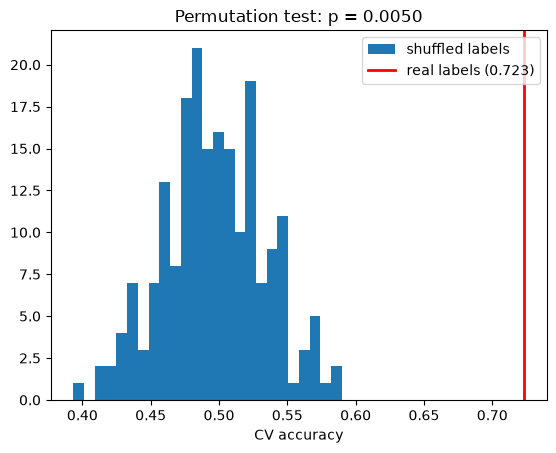

In [8]:
from sklearn.model_selection import permutation_test_score
score, perm_scores, pval = permutation_test_score(LogisticRegression(max_iter=1000), X[:300], y[:300],
                                                  cv=5, n_permutations=200, random_state=0)
plt.hist(perm_scores, bins=25, label="shuffled labels"); plt.axvline(score, c="r", lw=2, label=f"real labels ({score:.3f})")
plt.legend(); plt.title(f"Permutation test: p = {pval:.4f}"); plt.xlabel("CV accuracy"); plt.show()

### Effect size: statistical vs practical significance
With huge samples, tiny useless differences become "significant". Always report an **effect size** (Cohen's d, difference in accuracy with CI).

In [9]:
def cohens_d(a, b):
    sp = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    return (b.mean() - a.mean()) / sp

for n in [50, 500, 50000]:
    a, b = rng.normal(0, 1, n), rng.normal(0.03, 1, n)
    print(f"n={n:>6}: p = {stats.ttest_ind(a, b).pvalue:.4f}, Cohen's d = {cohens_d(a, b):.3f}")

n=    50: p = 0.0448, Cohen's d = 0.407
n=   500: p = 0.0609, Cohen's d = 0.119
n= 50000: p = 0.0000, Cohen's d = 0.031


At n = 50,000 the p-value is tiny, but d = 0.03 is negligible. **"Significant" does not mean "important".**

### Power analysis: how many test samples do I need?

In [10]:
from statsmodels.stats.power import TTestIndPower
for d in [0.2, 0.5, 0.8]:
    n_req = TTestIndPower().solve_power(effect_size=d, alpha=0.05, power=0.8)
    print(f"effect size d = {d}: need n = {np.ceil(n_req):.0f} per group for 80% power")

effect size d = 0.2: need n = 394 per group for 80% power
effect size d = 0.5: need n = 64 per group for 80% power
effect size d = 0.8: need n = 26 per group for 80% power


## **Practice Problems**
1. Two fertilisers give yields `rng.normal(3.1, 0.4, 25)` and `rng.normal(3.4, 0.4, 25)`. Test the difference (Welch and Mann-Whitney).
2. Build the McNemar table for LogisticRegression vs a `DecisionTreeClassifier(max_depth=3)` on the data above. Is the difference significant?
3. Apply BH correction to 1000 p-values drawn from `rng.uniform(size=1000)`. How many survive?
4. *(Advanced)* Write a custom permutation test for the difference in means of problem 1 (10,000 shuffles).

In [11]:
# Solution 1
f1, f2 = rng.normal(3.1, 0.4, 25), rng.normal(3.4, 0.4, 25)
print("Welch p:", round(stats.ttest_ind(f1, f2, equal_var=False).pvalue, 4), "| Mann-Whitney p:", round(stats.mannwhitneyu(f1, f2).pvalue, 4))
# Solution 2
from sklearn.tree import DecisionTreeClassifier
pt = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_tr, y_tr).predict(X_te) == y_te
t2 = [[np.sum(ca & pt), np.sum(ca & ~pt)], [np.sum(~ca & pt), np.sum(~ca & ~pt)]]
print("McNemar p:", mcnemar(t2, exact=False).pvalue)
# Solution 3
print("Survive BH:", multipletests(rng.uniform(size=1000), method="fdr_bh")[0].sum())
# Solution 4
obs = f2.mean() - f1.mean(); pooled = np.r_[f1, f2]; cnt = 0
for _ in range(10000):
    rng.shuffle(pooled); cnt += abs(pooled[25:].mean() - pooled[:25].mean()) >= abs(obs)
print(f"Permutation p = {cnt / 10000:.4f}")

Welch p: 0.0008 | Mann-Whitney p: 0.0011
McNemar p: 0.9278614893440519
Survive BH: 1
Permutation p = 0.0008


## **Key References**
- Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation*, 10(7), 1895-1923.
- Foody, G. M. (2004). Thematic map comparison: Evaluating the statistical significance of differences in classification accuracy. *Photogrammetric Engineering & Remote Sensing*, 70(5), 627-633.
- Benjamini, Y., & Hochberg, Y. (1995). Controlling the false discovery rate. *Journal of the Royal Statistical Society B*, 57(1), 289-300.
- Wasserstein, R. L., & Lazar, N. A. (2016). The ASA statement on p-values: Context, process, and purpose. *The American Statistician*, 70(2), 129-133.
- Demsar, J. (2006). Statistical comparisons of classifiers over multiple data sets. *Journal of Machine Learning Research*, 7, 1-30.